In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/passwords_clean.csv")

In [6]:
df.head()

,password,label
0,12345,weak
1,password,weak
2,abc123,medium
3,hello@123,medium
4,Strong@123,strong


In [7]:
df["length"] = df["password"].apply(len)

In [8]:
print(df.columns)

Index(['password', 'label', 'length'], dtype='str')


In [9]:
print(df.shape)

(6, 3)


In [10]:
df["uppercase_count"] = df["password"].apply(
    lambda x: sum(c.isupper() for c in x)
)

In [11]:
df.head()

,password,label,length,uppercase_count
0,12345,weak,5,0
1,password,weak,8,0
2,abc123,medium,6,0
3,hello@123,medium,9,0
4,Strong@123,strong,10,1


In [18]:
df["lowercase_count"] = df["password"].apply(
    lambda x: sum(c.islower() for c in x)
)

In [20]:
df["digit_count"] = df["password"].apply(
    lambda x: sum(c.isdigit() for c in x)
)

In [21]:
df["special_count"] = df["password"].apply(
    lambda x: sum(not c.isalnum() for c in x)
)

In [22]:
df["unique_chars"] = df["password"].apply(
    lambda x: len(set(x))
)

In [23]:
df.head()

,password,label,length,uppercase_count,lowercase_count,digit_count,special_count,unique_chars
0,12345,weak,5,0,0,5,0,5
1,password,weak,8,0,8,0,0,7
2,abc123,medium,6,0,3,3,0,6
3,hello@123,medium,9,0,5,3,1,8
4,Strong@123,strong,10,1,5,3,1,10


In [26]:
import math

def calculate_entropy(password):
    if len(password) == 0:
        return 0

    probabilities = [
        password.count(char) / len(password)
        for char in set(password)
    ]

    entropy = -sum(
        p * math.log2(p)
        for p in probabilities
    )

    return entropy * len(password)

In [27]:
df["entropy"] = df["password"].apply(calculate_entropy)

In [28]:
df[["password", "entropy"]].head()

,password,entropy
0,12345,11.609640
1,password,22.000000
2,abc123,15.509775
3,hello@123,26.529325
4,Strong@123,33.219281


In [29]:
df["diversity_ratio"] = (
    df["unique_chars"] / df["length"]
)

In [30]:
df[["password","diversity_ratio"]].head()

,password,diversity_ratio
0,12345,1.000000
1,password,0.875000
2,abc123,1.000000
3,hello@123,0.888889
4,Strong@123,1.000000


In [31]:
feature_df = df[
    [
        "length",
        "uppercase_count",
        "lowercase_count",
        "digit_count",
        "special_count",
        "unique_chars",
        "entropy",
        "diversity_ratio"
    ]
]

In [32]:
feature_df.head()

,length,uppercase_count,lowercase_count,digit_count,special_count,unique_chars,entropy,diversity_ratio
0,5,0,0,5,0,5,11.609640,1.000000
1,8,0,8,0,0,7,22.000000,0.875000
2,6,0,3,3,0,6,15.509775,1.000000
3,9,0,5,3,1,8,26.529325,0.888889
4,10,1,5,3,1,10,33.219281,1.000000


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

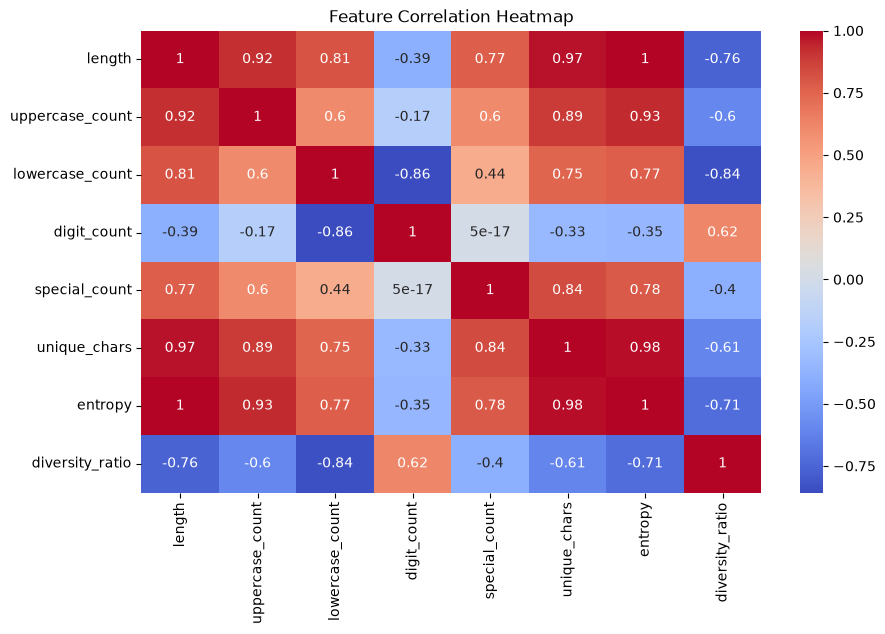

In [34]:
plt.figure(figsize=(10,6))

sns.heatmap(
    feature_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

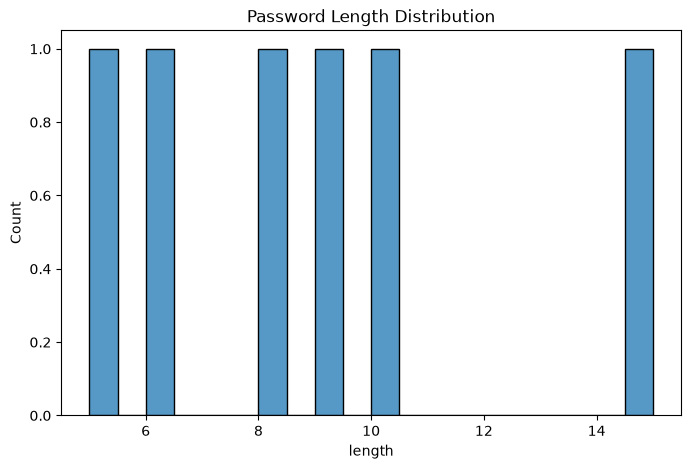

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["length"], bins=20)

plt.title("Password Length Distribution")
plt.show()

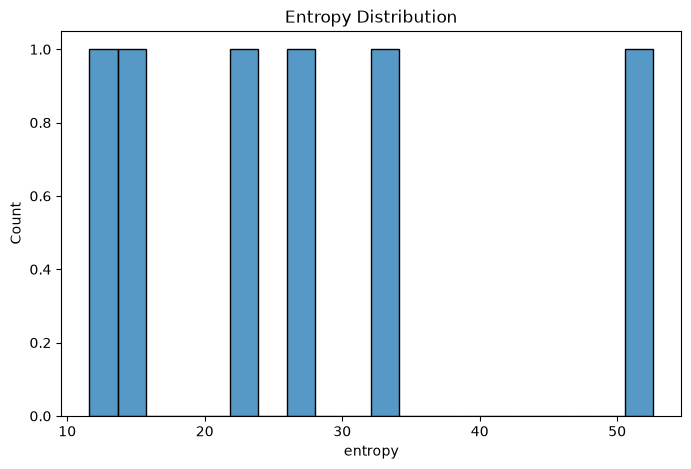

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["entropy"], bins=20)

plt.title("Entropy Distribution")
plt.show()

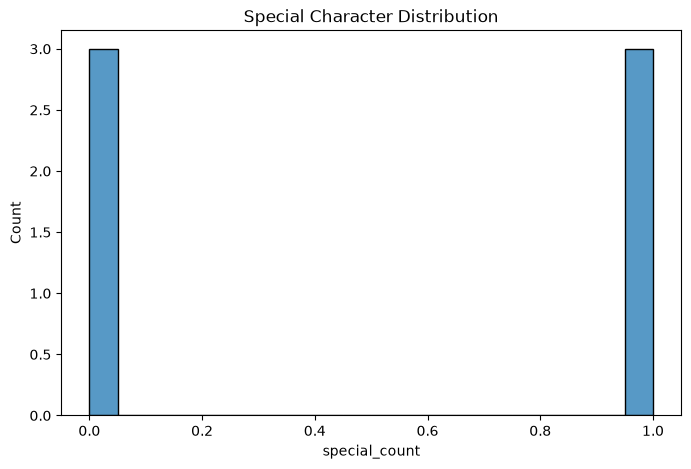

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df["special_count"], bins=20)

plt.title("Special Character Distribution")
plt.show()

In [39]:
df.to_csv(
    "../data/passwords_featured.csv",
    index=False
)